# Training Script and Evaluation

first setup 70:30 train, test split 

In [51]:
import os
from detectron2.config import get_cfg
from detectron2.engine import DefaultPredictor
from detectron2 import model_zoo

cfg = get_cfg()
cfg.merge_from_file(
    model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"))
cfg.MODEL.FREEZE_AT = 5
cfg.DATASETS.TRAIN = ("train", )
cfg.DATASETS.TEST = ("test",)
cfg.DATALOADER.NUM_WORKERS = 8
cfg.SOLVER.IMS_PER_BATCH = 4  # This is the real "batch size" commonly known to deep learning people
cfg.SOLVER.BASE_LR = 3e-5  # pick a good LR
cfg.SOLVER.MAX_ITER = 8000
cfg.SOLVER.STEPS = []  # do not decay learning rate
cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 512  # The "RoIHead batch size". 128 is faster, and good enough for this toy dataset (default: 512)
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 3
cfg.MODEL.WEIGHTS = "/home/abhinavchadaga/CS/fri_II/output/model_final.pth"
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.7   # set a custom testing threshold

predictor = DefaultPredictor(cfg)

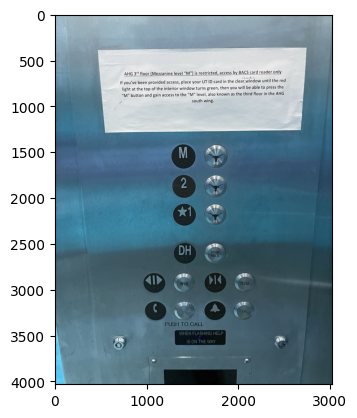

In [52]:
import cv2
import matplotlib.pyplot as plt
%matplotlib inline


img = cv2.imread("/home/abhinavchadaga/CS/fri_II/data/building_images/ahg/ahg_9.JPG")
plt.imshow(img)

In [33]:
from detectron2.utils.visualizer import Visualizer, ColorMode

v = Visualizer(img, instance_mode=ColorMode.IMAGE, scale=0.5)
outputs = predictor(img)
print(outputs["instances"].pred_boxes)
out = v.draw_instance_predictions(outputs["instances"].to("cpu"))
cv2.imwrite("output.png", out.get_image())


Boxes(tensor([[1283.5071, 2061.7310, 1530.3390, 2300.3713],
        [1295.8857, 2489.5891, 1533.4784, 2716.1250],
        [ 977.0552, 3125.6919, 1209.9763, 3333.7991],
        [1626.2733, 2813.5212, 1862.7366, 3030.8762],
        [ 960.0386, 2818.6780, 1198.4552, 3030.4177],
        [1272.4780, 1746.9476, 1526.9469, 1999.3602],
        [1263.3643, 1413.7385, 1525.5143, 1679.2360],
        [1623.5431, 3125.8301, 1858.0275, 3332.3931],
        [1955.7335, 2818.6494, 2176.2170, 3023.4861],
        [1627.3402, 2499.3689, 1850.1260, 2703.7678],
        [1290.0782, 2824.6577, 1514.7119, 3032.3259],
        [1623.1143, 1761.1764, 1870.1770, 1989.2266],
        [1623.3191, 1426.2288, 1878.1576, 1673.0963]], device='cuda:0'))


True

In [53]:
import torch
from torchvision import transforms as T

# prepare for the input
transform = T.Compose([T.ToTensor()])
input_im = transform(img)

# input_im = torch.unsqueeze(input_im, 0)
print(input_im.shape)

torch.Size([3, 4032, 3024])


In [54]:
from detectron2.modeling import build_model


model = build_model(cfg)
print(type(model))

<class 'detectron2.modeling.meta_arch.rcnn.GeneralizedRCNN'>


In [20]:
# from detectron2.config import get_cfg
# from detectron2.engine import DefaultPredictor
# import matplotlib.pyplot as plt
# import os
# import cv2
# %matplotlib inline

# cfg = get_cfg()
# cfg.MODEL.WEIGHTS = os.path.join(cfg.OUTPUT_DIR, "model_final.pth")
# cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.7  # set a custom testing threshold
# predictor = DefaultPredictor(cfg)

# img = cv2.imread(test_set[10]["file_name"])
# outputs = predictor(img)
# v = Visualizer(img_rgb=img[:, :, ::-1],
#                metadata=MetadataCatalog.get("train"),
#                instance_mode=ColorMode.SEGMENTATION,
#                scale=0.50)
# output = v.draw_instance_predictions(outputs["instances"].to("cpu"))
# plt.imshow(output.get_image())


In [21]:
# from detectron2.evaluation import COCOEvaluator, inference_on_dataset
# from detectron2.data import build_detection_test_loader

# evaluator = COCOEvaluator("test", output_dir="./output")
# val_loader = build_detection_test_loader(cfg, "test")
# print(inference_on_dataset(predictor.model, val_loader, evaluator))